In [26]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [27]:
BASE_DIR = r"C:\Users\user\Desktop\biopigment\data"

# (A) pooled selection
POOLED = {
    150: ["0226", "0305", "0305-2"],
    300: ["0323", "0326", "0326-2", "0413", "0423", "0424"],
}
# (B) trusted single series per temperature
TRUSTED = {
    150: ["0226"],
    300: ["0326-2"],
}

PEAK_LO, PEAK_HI = 450, 550
AUC_LO, AUC_HI = 200, 700

In [28]:
def load_spectrum(filepath):
    try:
        df = pd.read_csv(filepath, sep="\t", header=None,
                         names=["wavelength", "absorbance"], comment="#")
        df = df[pd.to_numeric(df["wavelength"], errors="coerce").notna()]
        df = df.astype(float).sort_values("wavelength").reset_index(drop=True)
        return df["wavelength"].to_numpy(), df["absorbance"].to_numpy()
    except Exception as e:
        print(f"  [error] {os.path.basename(filepath)}: {e}")
        return None


def parse_minutes(filename):
    m = re.search(r"(\d+)min", filename)
    return int(m.group(1)) if m else None


def collect(dates):
    by_time, wl_ref = {}, None
    for date in dates:
        folder = os.path.join(BASE_DIR, date)
        for fp in glob.glob(os.path.join(folder, "starlab-absorbance-carotene-*.txt")):
            minutes = parse_minutes(os.path.basename(fp))
            if minutes is None:
                continue
            spec = load_spectrum(fp)
            if spec is None:
                continue
            wl, ab = spec
            if wl_ref is None:
                wl_ref = wl
            elif not np.array_equal(wl, wl_ref):
                ab = np.interp(wl_ref, wl, ab)
            by_time.setdefault(minutes, []).append(ab)
    mean_spec = {t: np.mean(np.vstack(v), axis=0) for t, v in by_time.items()}
    counts = {t: len(v) for t, v in by_time.items()}
    return mean_spec, wl_ref, counts


In [29]:
def metrics(mean_spec, wl):
    pmask = (wl >= PEAK_LO) & (wl <= PEAK_HI)
    amask = (wl >= AUC_LO) & (wl <= AUC_HI)
    wl_auc = wl[amask]
    times = np.array(sorted(mean_spec))
    peak = np.array([mean_spec[t][pmask].mean() for t in times])
    auc = np.array([np.trapezoid(mean_spec[t][amask], wl_auc) for t in times])
    return times, peak, auc


def first_order(t, A0, k):
    return A0 * np.exp(-k * t)


def fit_decay(times, values):
    norm = values / values[0]
    popt, pcov = curve_fit(first_order, times, norm, p0=[1.0, 0.01], maxfev=10000)
    perr = np.sqrt(np.diag(pcov))
    # R^2
    resid = norm - first_order(times, *popt)
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((norm - norm.mean())**2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return popt[0], popt[1], perr[1], norm, r2

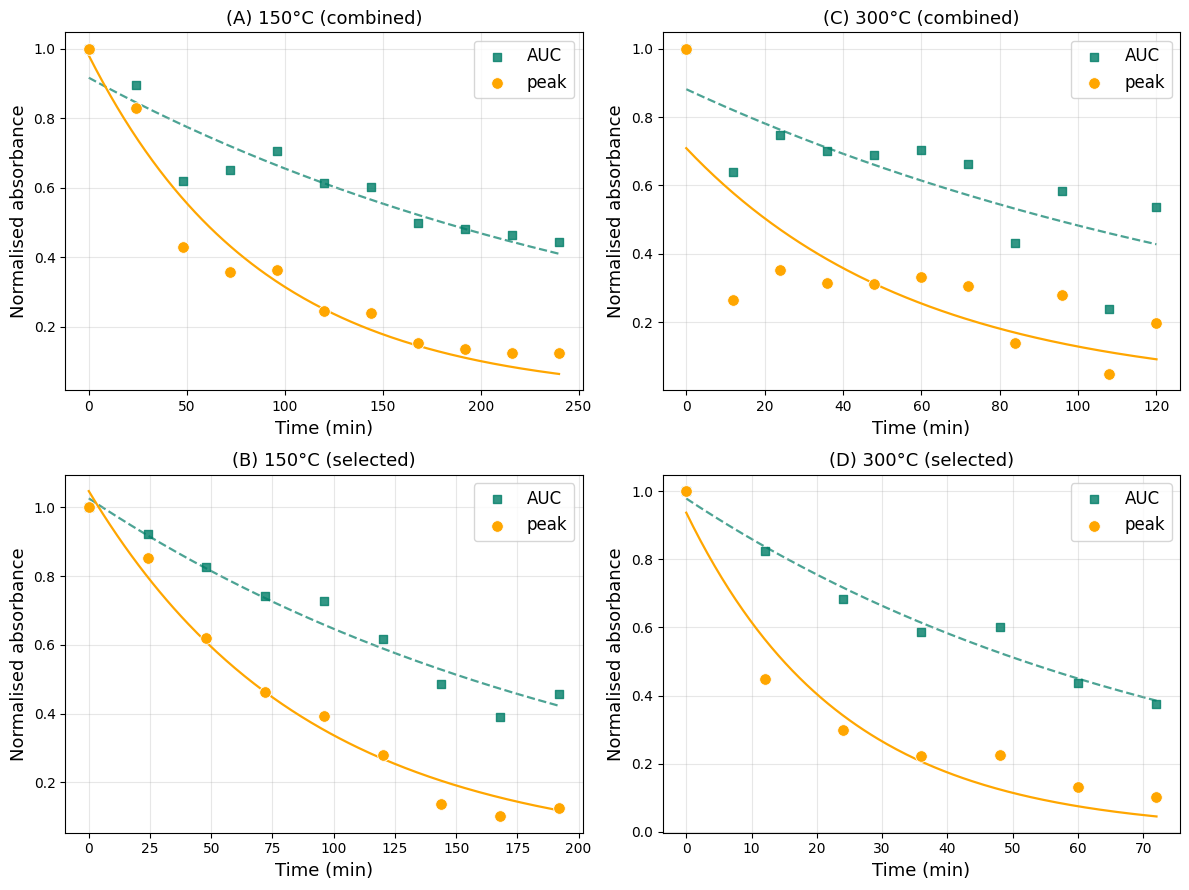


Panel    Mode       T(C)   k_peak      k_auc       Ratio    R²_peak   R²_auc   
?        combined   150    0.01136     0.00335     3.389    0.952     0.856    
?        selected   150    0.01133     0.00462     2.455    0.982     0.956    
?        combined   300    0.01706     0.00602     2.833    0.571     0.613    
?        selected   300    0.04200     0.01295     3.244    0.936     0.969    


In [30]:
# 파일 상단에 PALETTE 추가
PALETTE = {
    "dark":  "#003d5c",
    "teal1": "#005d71",
    "teal2": "#007d67",
    "green": "#1a983f",
    "olive": "#92a800",
    "orange":"#ffa600",
}

def panel(ax, mean_spec, wl, temp, mode_label, panel_char):  # panel_char 추가
    if wl is None or not mean_spec:
        ax.text(0.5, 0.5, "No data", ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        return None
    
    times, peak, auc = metrics(mean_spec, wl)
    A0p, kp, kep, peak_n, r2p = fit_decay(times, peak)
    A0a, ka, kea, auc_n, r2a = fit_decay(times, auc)
    ratio = kp / ka
    tt = np.linspace(times.min(), times.max(), 200)
    
    ax.scatter(times, auc_n, color=PALETTE["teal2"], s=35, marker="s",
               label="AUC", zorder=2, alpha=0.8)
    ax.plot(tt, first_order(tt, A0a, ka), color=PALETTE["teal2"], 
            linestyle="--", lw=1.6, zorder=1, alpha=0.7)
    
    ax.scatter(times, peak_n, color=PALETTE["orange"], s=70, label="peak",
               edgecolors="white", linewidths=0.6, zorder=4)
    ax.plot(tt, first_order(tt, A0p, kp), color=PALETTE["orange"], 
            linestyle="-", lw=1.6, zorder=3)
    
    ax.set_title(f"({panel_char}) {temp}°C ({mode_label})", 
                 fontsize=13)
    ax.set_xlabel("Time (min)", fontsize=13)
    ax.set_ylabel("Normalised absorbance", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12, loc='best')
    
    return dict(temp=temp, mode=mode_label, k_peak=kp, k_auc=ka, ratio=ratio,
                r2_peak=r2p, r2_auc=r2a)


def run():
    temps = [150, 300]
    fig, axes = plt.subplots(2, len(temps), figsize=(12, 9), squeeze=False)
    
    panel_chars = ['A', 'B', 'C', 'D']
    panel_idx = 0
    
    rows = []
    for col, temp in enumerate(temps):
        ms_p, wl_p, _ = collect(POOLED[temp])
        r = panel(axes[0][col], ms_p, wl_p, temp, "combined", panel_chars[panel_idx])
        if r: rows.append(r)
        panel_idx += 1
        
        ms_t, wl_t, _ = collect(TRUSTED[temp])
        r = panel(axes[1][col], ms_t, wl_t, temp, "selected", panel_chars[panel_idx])
        if r: rows.append(r)
        panel_idx += 1

    axes[0][0].set_ylabel("Normalised absorbance", fontsize=13)
    axes[1][0].set_ylabel("Normalised absorbance", fontsize=13)

    fig.tight_layout(rect=[0, 0, 1, 1])
    plt.savefig("peak_auc_compare.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"\n{'Panel':<8} {'Mode':<10} {'T(C)':<6} {'k_peak':<11} {'k_auc':<11} "
          f"{'Ratio':<8} {'R²_peak':<9} {'R²_auc':<9}")
    print("="*80)
    for r in rows:
        print(f"{r.get('panel', '?'):<8} {r['mode']:<10} {r['temp']:<6} {r['k_peak']:<11.5f} "
              f"{r['k_auc']:<11.5f} {r['ratio']:<8.3f} {r['r2_peak']:<9.3f} {r['r2_auc']:<9.3f}")
    print("="*80)


if __name__ == "__main__":
    run()